In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import copy

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,classification_report,ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchaudio.transforms as T

from torch.utils.data import Dataset,DataLoader

from tqdm.notebook import tqdm
from matplotlib import  pyplot  as plt
SR = 22050
DURATION = 30

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("kgg_key")
secret_value_1 = user_secrets.get_secret("kgg_user")
secret_value_2 = user_secrets.get_secret("WANDB_API_KEY")


#============ Check for GPU availability ==============================#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    print("GPU is available.Setting RANDOM_SEED .... ")
        # setting for both CPU and GPU
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   Running on CPU")
print("\n✅ Environment setup complete!")

import warnings
warnings.filterwarnings("ignore")

🚀 Using device: cuda
GPU is available.Setting RANDOM_SEED .... 
   GPU: Tesla T4
   Memory: 14.6 GB

✅ Environment setup complete!


First Neural Network & CNNs!

* Learn PyTorch basics: Tensors, Dataset (custom loader for training), DataLoader.
* Convert audio to 2D/1D Mel-Spectrograms.
* Build a simple CNN (Convolutional Neural Network)/NN (Neural Network) to process the spectrograms.
* Implement training loop, loss, optimizer, and wandb logging.
* Train and evaluate your CNN/NN (Neural Network)model.

# Definition

## - Utility

In [2]:
def extract_paths(pc=15000,test_size=0.2):
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
    train_paths = []
    val_paths = []
    count = 0
    tr_count = 0
    val_count = 0
    
    paths_count = pc
    test_size = paths_count*test_size
    train_size = paths_count - test_size
    
    for g in GENRES:
        root_dir_path = f"/kaggle/input/datasets/akashkumbhakar/{g}-mel-15000"
        for i in range(0,paths_count):
            file_name = f"mashup_{i}.wav.npy"
            path = os.path.join(root_dir_path,file_name)
            if i >= train_size:
                val_paths.append((path,g))
                val_count += 1
            else : 
                train_paths.append((path,g))
                tr_count += 1
            count += 1
    print("Total paths (music files) : ", count)
    print("Total training files : ", tr_count)
    print("Total validation files : ", val_count)
    return train_paths,val_paths

def check_split():
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
    g_c = {}
    for i in tr:
        if i[1] in g_c.keys():
            g_c[i[1]] += 1
        else:
            g_c[i[1]] = 1
    return g_c

def genre_to_idx(str_label):
    genre_to_id = {'blues':0, 'classical':1, 'country':2, 'disco':3, 'hiphop':4,'jazz':5, 'metal':6, 'pop':7, 'reggae':8, 'rock':9}
    y = genre_to_id[str_label]

    return y

def idx_to_genre(targets):
    id_to_genre = {0:'blues', 1:'classical', 2:'country', 3:'disco', 4:'hiphop',5:'jazz', 6:'metal', 7:'pop', 8:'reggae', 9:'rock'}
    y = [id_to_genre[id] for id in targets]

    return y    

## - Dataset and DataLoader

In [3]:
class MelDataset(Dataset):
    def __init__(self,paths,transform):  # paths : List[(path,label)]
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self,idx):
        mel = np.load(self.paths[idx][0])
        label = genre_to_idx(self.paths[idx][1])
        #mel = torch.from_numpy(mel).float()
        mel = self.transform(mel)
        label = torch.tensor(label, dtype=torch.long)
        return mel,label

data_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[-45.60], std=[16.60])
])
print("✅ dataset defined.")

✅ dataset defined.


## - Coonfig

In [4]:
config = {
    "model_name" : "ast-finetune",
    "version" : 'v1',
    "batch_size" : 20,
    "lr" : 0.0001,
    "sample_count" : 0,
    "epochs" : 5,
    "log_wandb" : False,
    "description" : None
}

try:
    dir_path = f"/kaggle/working/{config['model_name']}"
    os.makedirs(dir_path, exist_ok=True)
    print(f"✅ Directory created at: {dir_path}")
except Exception as e:
    print(f"Error creating directory: {e}")


✅ Directory created at: /kaggle/working/ast-finetune


In [5]:
train_paths,val_paths = extract_paths(pc=1000)

train_dataset = MelDataset(train_paths,data_transformer)
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)
val_dataset = MelDataset(val_paths,data_transformer)
val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)
config['sample_count'] = len(train_paths)
print(f"✅ BATCH SIZE : {config['batch_size']} | Size of Train Dataloader : {len(train_loader)}  |  Size of Val Dataloader : {len(val_loader)}")

Total paths (music files) :  10000
Total training files :  8000
Total validation files :  2000
✅ BATCH SIZE : 20 | Size of Train Dataloader : 400  |  Size of Val Dataloader : 100


## - Model

#### -- loading resnet model

In [6]:
from transformers import ASTConfig, ASTForAudioClassification
# -- Configure AST for input ---
num_labels = 10
ast_config = ASTConfig.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=num_labels,
    max_length=646   
)

ast_model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    config=ast_config,
    ignore_mismatched_sizes=True
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                                                          | Status   |                                                                                                  
-------------------------------------------------------------+----------+--------------------------------------------------------------------------------------------------
classifier.dense.bias                                        | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])                  
audio_spectrogram_transformer.embeddings.position_embeddings | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1, 1214, 768]) vs model:torch.Size([1, 770, 768])
classifier.dense.weight                                      | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])        

Notes:
- MISMATCH	:ckpt weights were loaded, but they d

In [8]:
ast_model.classifier.dense

Linear(in_features=768, out_features=10, bias=True)

In [7]:
class MelAST(nn.Module):
    def __init__(self,ast_model,num_classes):
        super().__init__()
        #for param in ast_model.parameters():
            #param.requires_grad = False

        
        ast_model.classifier.dense = nn.Linear(in_features=768, out_features=10, bias=True)
        self.ast = ast_model

    def forward(self,x):
        batch,channel,freq,time = x.size()
        #print(batch,channel,freq,time)
        #x_ast_in = x.permute(0, 1, 3, 2)
        x = x.squeeze(1)
        #print(x_ast_in.size())
        
        out_logit = self.ast(x)

        return out_logit
model = MelAST(ast_model,10)
grad_param_count = 0
total_pram_count = 0
for name,p in model.named_parameters():
    mark = ""
    total_pram_count += p.numel()
    if p.requires_grad:
        mark = "[RG]" # [RG] for gradient computation
        grad_param_count += p.numel()
    print(mark," ",name," - ",p.size()," - ",p.numel())

print(f"\nTotal Parameter : {total_pram_count}\nParameters with Gradient : {grad_param_count}")

[RG]   ast.audio_spectrogram_transformer.embeddings.cls_token  -  torch.Size([1, 1, 768])  -  768
[RG]   ast.audio_spectrogram_transformer.embeddings.distillation_token  -  torch.Size([1, 1, 768])  -  768
[RG]   ast.audio_spectrogram_transformer.embeddings.position_embeddings  -  torch.Size([1, 770, 768])  -  591360
[RG]   ast.audio_spectrogram_transformer.embeddings.patch_embeddings.projection.weight  -  torch.Size([768, 1, 16, 16])  -  196608
[RG]   ast.audio_spectrogram_transformer.embeddings.patch_embeddings.projection.bias  -  torch.Size([768])  -  768
[RG]   ast.audio_spectrogram_transformer.encoder.layer.0.attention.attention.query.weight  -  torch.Size([768, 768])  -  589824
[RG]   ast.audio_spectrogram_transformer.encoder.layer.0.attention.attention.query.bias  -  torch.Size([768])  -  768
[RG]   ast.audio_spectrogram_transformer.encoder.layer.0.attention.attention.key.weight  -  torch.Size([768, 768])  -  589824
[RG]   ast.audio_spectrogram_transformer.encoder.layer.0.attenti

## - Training

In [8]:
def train(model,train_loader,val_loader,loss_fn, optimizer,config):
    train_loss = []
    train_f1_score = []
    max_f1 = 0.0
    best_model_state = None
    best_optim_state = None
    best_train_loss = None
    best_val_loss = None
    # initialization of wandb
    log_wandb = config["log_wandb"]
    run = None
    if log_wandb:
        run = wandb.init(
            entity="23f1001065-indian-institute-of-technology-madras",
            project="23f1001065-t12026",
            name=config['run_name'],
            config = config
        )
    num_epochs = config['epochs']
    for epoch in range(num_epochs):
        running_loss = 0.0
        model.train()
        
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader),desc=f"Epoch {epoch+1}/{num_epochs}")
        for i,(mels,labels) in progress_bar:
            mels , labels = mels.to(device,non_blocking=True), labels.to(device,non_blocking=True)
            optimizer.zero_grad()
            
            outputs = model(mels).logits
            loss = loss_fn(outputs, labels)
        
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            avg_loss = running_loss / (i + 1)

            progress_bar.set_postfix({
                'loss': f"{avg_loss:.4f}"
            })
        loss = running_loss / len(train_loader)
        t,p,f1score,val_loss = validation(model,val_loader,criterion)
        print(f"Train Loss: {loss:.4f}")
        # Upload metrics
        if run:
            run.log({
                "train_loss" : float(loss),
                "val_loss" : float(val_loss),
                "f1_score" : float(f1score)
            })
        if f1score > max_f1 + 0.001 :
            max_f1 = f1score
            best_train_loss = loss
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_optim_state = copy.deepcopy(optimizer.state_dict())
    # Close Wandb
    if run:
        run.finish()
    return (best_model_state,
            best_optim_state,
            best_train_loss,
            best_val_loss,
            max_f1)
print("✅ Train function defined.")

✅ Train function defined.


## - Evaluation

In [9]:
def validation(model,val_loader,loss_fn):
    val_loss = 0.0
    all_true = []
    all_pred = []
    with torch.no_grad():
        progress_bar = tqdm(enumerate(val_loader), total=len(val_loader),desc=f"Validation")
        model.eval()
        
        for i,(mels,labels) in progress_bar:
            mels,labels = mels.to(device,non_blocking=True),labels.to(device,non_blocking=True)
            output = model(mels).logits
            loss = loss_fn(output,labels)

            probs = torch.softmax(output,dim=1) 
            predicted_y = torch.argmax(probs,dim=1)
            
            val_loss += loss.item()
            avg_loss = val_loss / (i + 1)

            progress_bar.set_postfix({
                'loss': f"{avg_loss:.4f}"
            })

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(predicted_y.cpu().numpy())
        #all_true = torch.cat(all_true,dim=0)
        #all_pred = torch.cat(all_pred,dim=0).cpu().numpy()
        #print(len(all_true),len(all_pred))
    
        loss = val_loss/len(val_loader)
        f1score = f1_score(all_true,all_pred,average='macro')

        print(f"Validation Loss : {loss},  F1_score : {f1score}")
        return all_true,all_pred,f1score,loss
        
print("✅ Validation function defined.")
            

✅ Validation function defined.


# Wandb login

In [10]:
while True:
    choice = input("Dou you want to log at WanDb[YES/NO] ?")
    if choice in ['YES','NO']:
        break
    else:
        print("Invalid input : Please enter 'YES' or 'NO'.")
if choice == 'YES':
    config["log_wandb"] = True
    print("Continuing....")
    import wandb
    print(f"Wandb version: {wandb.__version__}")
    wandb.login(key=secret_value_2)
else:
    config["log_wandb"] = False
    print("Aborting.")

Dou you want to log at WanDb[YES/NO] ? YES


Continuing....
Wandb version: 0.24.0


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f1001065 (23f1001065-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Training

## - Setup

In [11]:
model = MelAST(ast_model,10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
run_name = "-".join([str(attribute) for attribute in list(config.values())[:6]])
config['run_name'] = run_name
print("Run Name : ",run_name)

print("✅ model,optimizer and loss_function instance created.")

Run Name :  ast-finetune-v1-20-0.0001-8000-5
✅ model,optimizer and loss_function instance created.


## - Training loop execution

In [12]:
best_model_state,best_optim_state,train_loss,val_loss,f1 = train(model,train_loader,val_loader,criterion, optimizer,config)

Epoch 1/5:   0%|          | 0/400 [00:00<?, ?it/s]

Validation:   0%|          | 0/100 [00:00<?, ?it/s]

Validation Loss : 0.40386303432285786,  F1_score : 0.8469247417168111
Train Loss: 0.8900


Epoch 2/5:   0%|          | 0/400 [00:00<?, ?it/s]

Validation:   0%|          | 0/100 [00:00<?, ?it/s]

...

Validation Loss : 0.2379938095714897,  F1_score : 0.9166864317474988
Train Loss: 0.1063


Epoch 5/5:   0%|          | 0/400 [00:00<?, ?it/s]

Validation:   0%|          | 0/100 [00:00<?, ?it/s]

Validation Loss : 0.14853651315439492,  F1_score : 0.9450983079733135
Train Loss: 0.0493


f1_score,▁▆▇▆█
train_loss,█▃▂▁▁
val_loss,█▃▂▃▁
f1_score,0.9451
train_loss,0.0493
val_loss,0.14854


# Validating best model state dict

In [14]:
b_model = MelAST(ast_model,10).to(device)
b_model.load_state_dict(best_model_state)

<All keys matched successfully>

In [15]:
all_true,all_pred,f1score,loss = validation(b_model,val_loader,criterion)

Validation:   0%|          | 0/100 [00:00<?, ?it/s]

Validation Loss : 0.14853651430457832,  F1_score : 0.9450983079733135


              precision    recall  f1-score   support

       blues       0.98      0.93      0.95       200
   classical       1.00      0.97      0.99       200
     country       0.94      0.95      0.95       200
       disco       0.88      0.96      0.92       200
      hiphop       0.96      0.97      0.97       200
        jazz       0.95      1.00      0.97       200
       metal       0.99      0.96      0.98       200
         pop       0.89      0.99      0.94       200
      reggae       0.95      0.91      0.93       200
        rock       0.94      0.81      0.87       200

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



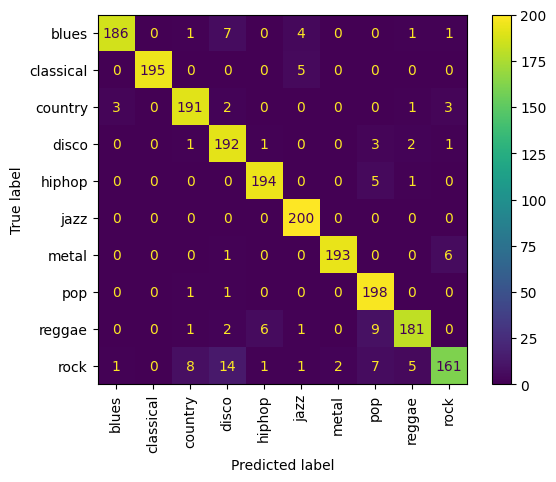

In [16]:
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
cr = classification_report(idx_to_genre(all_true),idx_to_genre(all_pred),labels=classes)
print(cr)
ConfusionMatrixDisplay.from_predictions(idx_to_genre(all_true),idx_to_genre(all_pred),labels=classes,xticks_rotation='vertical')
plt.show()

# Saving model

In [17]:
model_name = config['model_name']
if os.path.exists(f"/kaggle/working/{model_name}"):
    checkpoint={
        'run_name' : run_name,
        'epoch' : config['epochs'],
        'train_loss' : train_loss,
        'val_loss' : val_loss,
        'f1_score' : f1,
        'model_state_dict' : best_model_state,
        'optimizer_state_dict' : best_optim_state
    }
    torch.save(checkpoint, f"/kaggle/working/{model_name}/checkpoint.pth")
    print(f"✅ {model_name} saved.")
else:
    print(f"Path not exists.")

✅ ast-finetune saved.


# Uploading to KaggleHub

In [18]:
import kagglehub

# Replace with path to directory containing model files.
model_name = config['model_name']
LOCAL_MODEL_DIR = f'/kaggle/working/{model_name}'

MODEL_SLUG = model_name # Replace with model slug.

# Learn more about naming model variations at
# https://www.kaggle.com/docs/models#name-model.
VARIATION_SLUG = 'default' # Replace with variation slug.

kagglehub.model_upload(
  handle = f"akashkumbhakar/{MODEL_SLUG}/pyTorch/{VARIATION_SLUG}",
  local_model_dir = LOCAL_MODEL_DIR,
  version_notes = '')

Uploading Model https://api.kaggle.com/models/akashkumbhakar/ast-finetune/pyTorch/default ...
Model 'ast-finetune' does not exist or access is forbidden for user 'akashkumbhakar'. Creating or handling Model...
Model 'ast-finetune' Created.
Starting upload for file /kaggle/working/ast-finetune/checkpoint.pth


Uploading: 100%|██████████| 1.03G/1.03G [00:09<00:00, 110MB/s]

Upload successful: /kaggle/working/ast-finetune/checkpoint.pth (983MB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/akashkumbhakar/ast-finetune/pyTorch/default
